In [1]:
import numpy as np
import matplotlib
import pandas as pd

In [2]:
dataset = pd.read_csv('/Users/eddie/Downloads/lake_erie_habs_W4_6_8_9_12_13_16_2013-2020.csv')

In [3]:
print(dataset)

          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804            1.6             18.5   
1    5/29/2013    41.8343    -83.3633            1.0             20.3   
2    5/29/2013    41.8267    -83.1930            1.5             19.8   
3    6/10/2013    41.7144    -83.3805            0.5             20.7   
4    6/10/2013    41.8353    -83.3631            0.7             23.5   
..         ...        ...         ...            ...              ...   
834  10/5/2020    41.7176    -83.4239            0.8             14.4   
835  10/5/2020    41.6599    -83.1468            1.8             15.4   
836  10/5/2020    41.7436    -83.1526            1.8             15.7   
837  10/5/2020    41.7040    -83.2552            1.0             15.2   
838  10/5/2020    41.8267    -83.1947            3.5             15.7   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [4]:
train = dataset.iloc[:743,:]
test = dataset.iloc[743:,:]
print(train)
print(test)

          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804           1.60             18.5   
1    5/29/2013    41.8343    -83.3633           1.00             20.3   
2    5/29/2013    41.8267    -83.1930           1.50             19.8   
3    6/10/2013    41.7144    -83.3805           0.50             20.7   
4    6/10/2013    41.8353    -83.3631           0.70             23.5   
..         ...        ...         ...            ...              ...   
738  10/7/2019    41.6599    -83.1467           1.00             18.2   
739  10/7/2019    41.7428    -83.1354           1.25             18.2   
740  10/7/2019    41.7023    -83.2639           1.25             18.5   
741  10/7/2019    41.8270    -83.1949           1.50             17.2   
742  6/16/2020    41.7054    -83.3864           0.20             20.3   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [5]:
X_train = pd.DataFrame(train.iloc[:,4:15].values)
Y_train = train.iloc[:,16:].values
print(X_train.shape)
print(Y_train.shape)

(743, 11)
(743, 1)


In [6]:
X_test = pd.DataFrame(test.iloc[:,4:15].values)
Y_test = test.iloc[:,16:].values
print(X_test.shape)
print(Y_test.shape)

(96, 11)
(96, 1)


In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import tensorflow as tf

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold, GridSearchCV
from numpy import absolute
from numpy import mean
from numpy import std

In [10]:
model = Ridge(alpha=0.01)
grid = dict()
grid['alpha'] = np.arange(0, 1, 0.01)

In [11]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

In [12]:
search = GridSearchCV(model, grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
print(search)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=Ridge(alpha=0.01), n_jobs=-1,
             param_grid={'alpha': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])},
             scoring='neg_mean_absolute_error')


In [13]:
results = search.fit(X_train, Y_train)
print(results)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=Ridge(alpha=0.01), n_jobs=-1,
             param_grid={'alpha': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])},
             scoring='neg_mean_absolute_error')


In [14]:
model.fit(X_train_scaled,Y_train)

Ridge(alpha=0.01)

In [15]:
res = model.predict(X_test_scaled)
print(res)

[-24.43505414   9.45851568  -2.84735483  40.69591869  41.03700369
  48.78828381  35.91356536  30.46300838  29.09749346  54.34946593
  22.29093341  45.92222076  22.72384756  38.48078552  26.97764761
  52.251456    26.59911909  47.96491616  33.30703119  39.72471832
  25.86010732  50.89319772  18.79440711  24.72092314  23.78442797
  28.22980644  53.48208999  32.83569999  53.71034004  30.05129504
  32.2401488   42.0395151   22.38004536  62.39764872  37.08732535
  57.15632158  37.38277595  40.88216708  43.67266271  23.45595331
  46.74393198  34.17045498  71.64966134  34.94420858  31.8165394
  35.86371718  24.27906207  39.09059366  34.41234563  60.95063151
  24.03444492  22.41274892  22.78993369  22.21034016  34.8505773
  34.87499324  54.88519576  32.69692512  25.50753395  35.27913253
  23.07304365  40.22813013  22.42933196  46.95953696  26.39300392
  24.78046343  30.58332551  19.67749721  36.92220307  39.21827103
  42.02955771  24.44742488  23.58769798  32.25581364  17.98323037
  44.1856192

In [16]:
print(Y_test)

[[29.9 ]
 [29.9 ]
 [ 1.53]
 [12.71]
 [21.54]
 [12.93]
 [12.9 ]
 [ 6.43]
 [10.83]
 [36.61]
 [ 1.86]
 [31.98]
 [11.43]
 [52.65]
 [ 7.87]
 [47.71]
 [10.54]
 [44.72]
 [12.61]
 [35.36]
 [14.3 ]
 [58.5 ]
 [ 4.64]
 [12.82]
 [10.81]
 [16.77]
 [64.22]
 [32.91]
 [66.79]
 [ 2.8 ]
 [24.77]
 [37.49]
 [ 3.56]
 [39.39]
 [15.67]
 [45.11]
 [14.5 ]
 [14.5 ]
 [21.39]
 [ 5.13]
 [43.03]
 [21.  ]
 [89.02]
 [31.28]
 [18.66]
 [19.5 ]
 [ 8.1 ]
 [45.37]
 [43.53]
 [96.43]
 [14.22]
 [12.49]
 [11.47]
 [12.79]
 [28.47]
 [18.85]
 [54.34]
 [13.85]
 [ 9.4 ]
 [17.49]
 [ 7.08]
 [41.6 ]
 [19.71]
 [38.09]
 [21.65]
 [ 8.65]
 [22.36]
 [ 3.47]
 [29.51]
 [26.78]
 [32.63]
 [22.69]
 [18.27]
 [25.42]
 [ 6.57]
 [ 8.27]
 [ 5.16]
 [28.08]
 [12.19]
 [24.83]
 [22.62]
 [ 0.77]
 [ 8.07]
 [11.42]
 [16.64]
 [ 4.25]
 [ 9.91]
 [ 6.15]
 [ 4.37]
 [ 9.95]
 [ 6.79]
 [ 9.98]
 [ 6.36]
 [ 3.91]
 [ 9.65]
 [ 1.74]]


In [17]:
from sklearn.metrics import r2_score 

In [18]:
r2 = r2_score(Y_test, res) 
print(r2)

0.24034344544123687


In [19]:
from sklearn.metrics import mean_absolute_error

In [20]:
mae = mean_absolute_error(Y_test,res)
print(mae)

13.415023299972574


In [21]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(Y_test,res)
print(mape)

1.5001865413441287


In [22]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(Y_test,res)
print(rmse)

15.953759616669604


In [23]:
features = pd.DataFrame(dataset.iloc[:,4:15])
features = features.columns
print(features)

Index(['CTD Temperature', 'CTD Specific Conductivity ',
       'CTD Dissolved Oxygen ', 'Turbidity ', 'Total Phosphorus',
       'Total Dissolved Phosphorus ', 'Ammonia', 'Nitrate + Nitrite ',
       'Particulate Organic Carbon ', 'Particulate Organic Nitrogen ',
       'Total Suspended Solids'],
      dtype='object')


In [24]:
import shap

c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
explainer = shap.LinearExplainer(model, X_train)
values = explainer.shap_values(X_train)


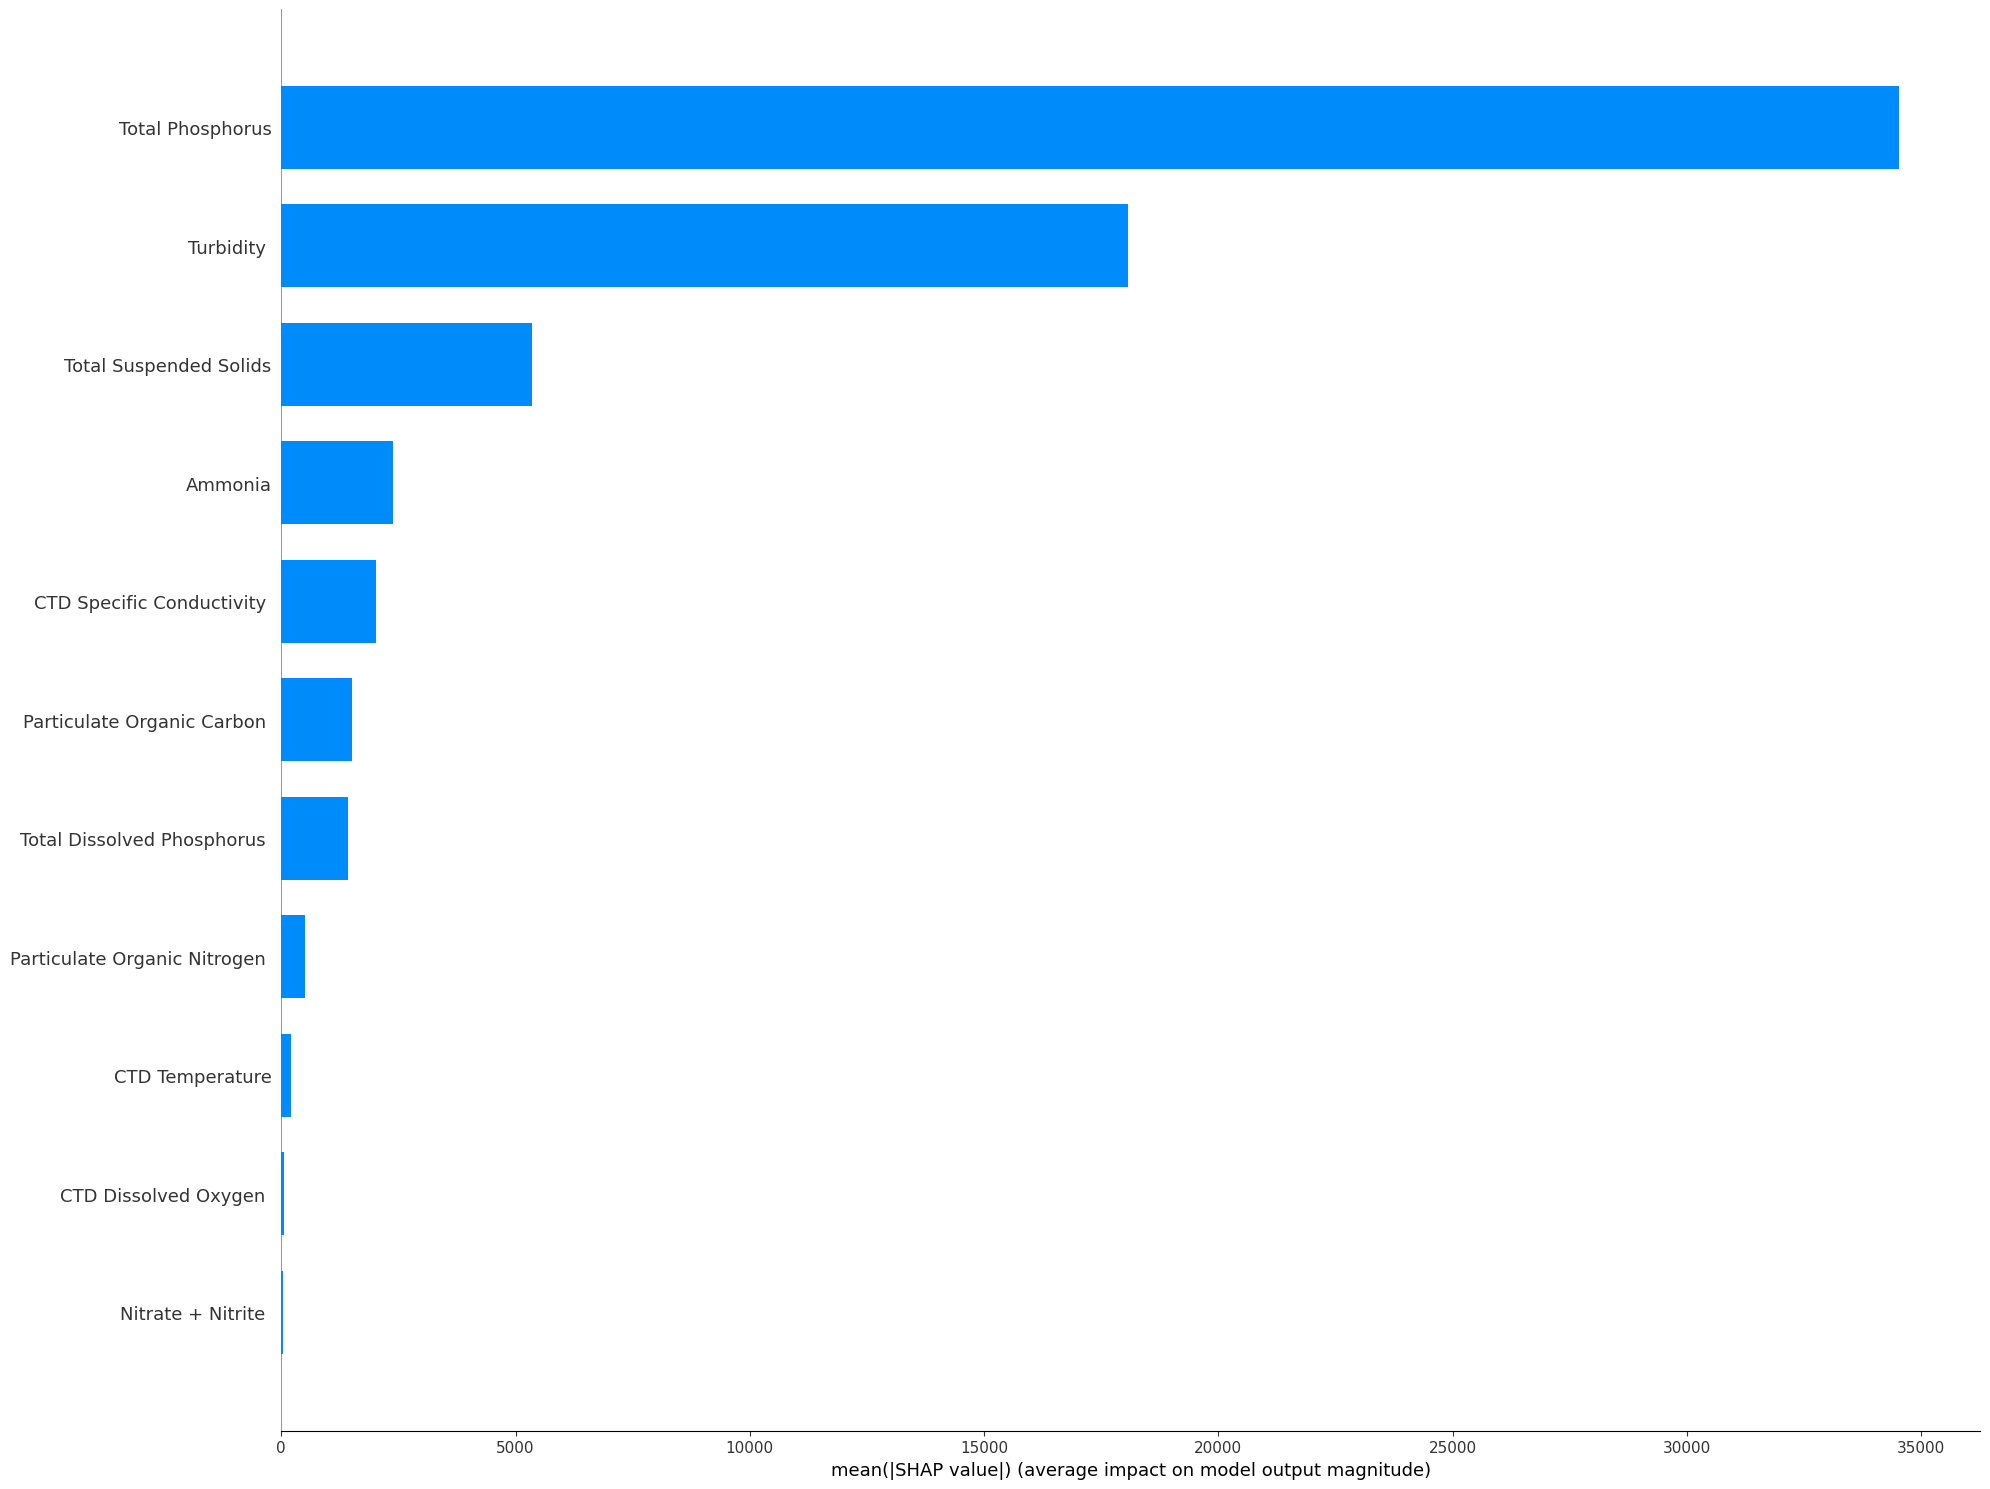

In [26]:
shap.summary_plot(values, X_train,feature_names = features,plot_type="bar",plot_size = (20,15),show=False)

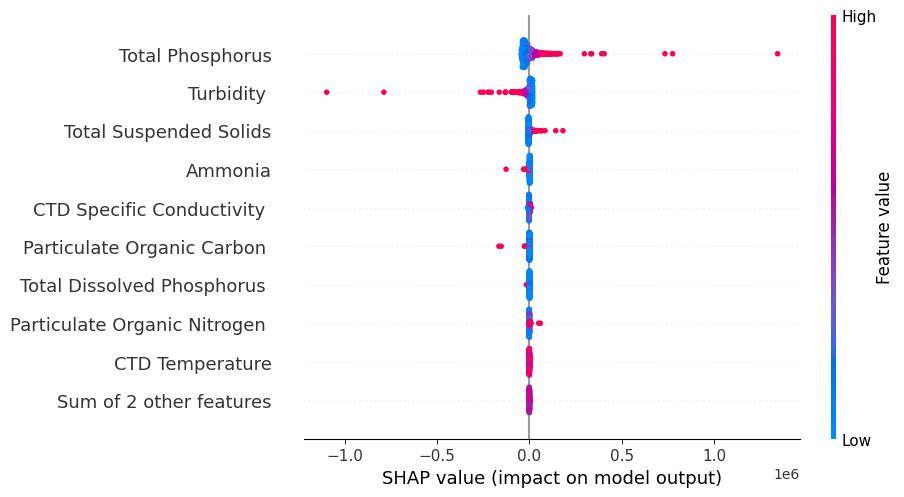

In [27]:
X_test_shap = pd.DataFrame(train.iloc[:,4:15])
shap_values = explainer(X_test_shap)
shap.plots.beeswarm(shap_values=shap_values)

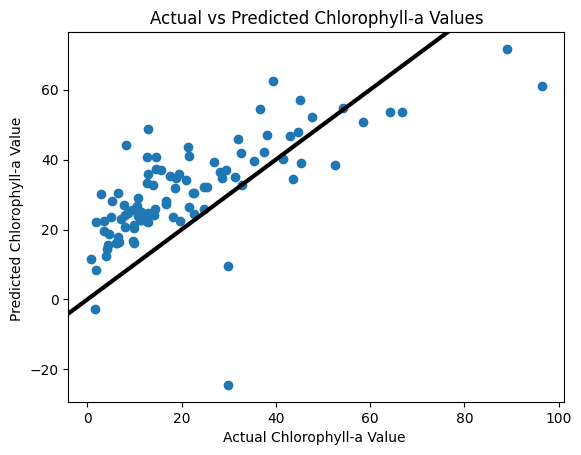

In [28]:
import matplotlib.pyplot as plt
plt.scatter(Y_test, res)
plt.xlabel('Actual Chlorophyll-a Value ')
plt.ylabel('Predicted Chlorophyll-a Value ')
plt.title('Actual vs Predicted Chlorophyll-a Values')
xpoints = ypoints = plt.xlim()
plt.plot(xpoints, ypoints, linestyle='-', color='k', lw=3, scalex=False, scaley=False)
plt.show()